In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
import urllib.request

import zipfile

url = "https://archive.ics.uci.edu/static/public/186/wine+quality.zip"

urllib.request.urlretrieve(url, "winequality.zip")

with zipfile.ZipFile("winequality.zip") as zip_ref:

  zip_ref.extractall("wine_data")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [4]:
df = pd.read_csv("wine_data/winequality-red.csv", sep=";")

print("Dataset loaded successfully!")

print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (1599, 12)


In [5]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 240


In [9]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [13]:
print("Wine Quality Distribution")

print("-------------------------")

print("Quality | Number of Wines")

print(df["quality"].value_counts().sort_index())

Wine Quality Distribution
-------------------------
Quality | Number of Wines
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


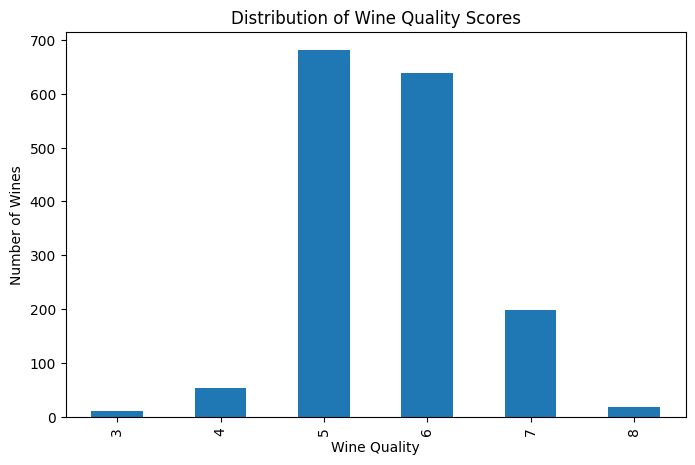

In [14]:
plt.figure(figsize=(8,5))

df["quality"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Wine Quality")

plt.ylabel("Number of Wines")

plt.title("Distribution of Wine Quality Scores")

plt.show()

In [15]:
X = df.drop("quality", axis=1)

y = df["quality"]

print("Features shape:", X.shape)

print("Target shape:", y.shape)

Features shape: (1599, 11)
Target shape: (1599,)


In [16]:
X_train_pool, X_test, y_train_pool, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training pool:", X_train_pool.shape)

print("Fixed test set:", X_test.shape)

Training pool: (1279, 11)
Fixed test set: (320, 11)


In [17]:
training_sizes = [20, 40, 60, 80, 100]

print("Training data sizes:", training_sizes)

Training data sizes: [20, 40, 60, 80, 100]


In [18]:
results = []

print("Results storage created successfully!")

Results storage created successfully!


In [20]:
for size in training_sizes:
  n_samples = int(len(X_train_pool) * size / 100)

  X_train = X_train_pool.iloc[:n_samples]

  y_train = y_train_pool.iloc[:n_samples]

  model = LinearRegression()

  model.fit(X_train, y_train)

  predictions = model.predict(X_test)

  mae = mean_absolute_error(y_test, predictions)

  rmse = np.sqrt(mean_squared_error(y_test, predictions))

  r2 = r2_score(y_test, predictions)

  results.append({

    "Training Size (%)": size,

    "Training Samples": n_samples,

    "MAE": mae,

    "RMSE": rmse,

    "R2": r2

  })

print("All 5 experiments completed successfully!")

All 5 experiments completed successfully!


In [21]:
results_df = pd.DataFrame(results)

results_df

,Training Size (%),Training Samples,MAE,RMSE,R2
0,20,255,0.522199,0.658878,0.335706
1,40,511,0.507722,0.640025,0.373178
2,60,767,0.509741,0.636702,0.379670
3,80,1023,0.504311,0.625997,0.400354
4,100,1279,0.503530,0.624520,0.403180


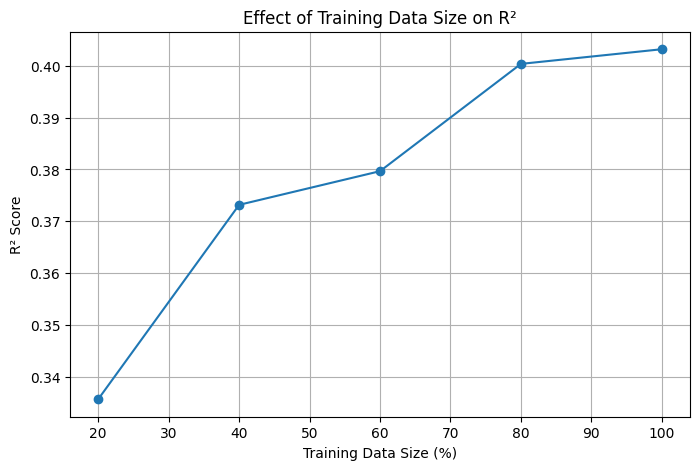

In [22]:
plt.figure(figsize=(8,5))

plt.plot(results_df["Training Size (%)"], results_df["R2"], marker="o")

plt.xlabel("Training Data Size (%)")

plt.ylabel("R² Score")

plt.title("Effect of Training Data Size on R²")

plt.grid(True)

plt.show()

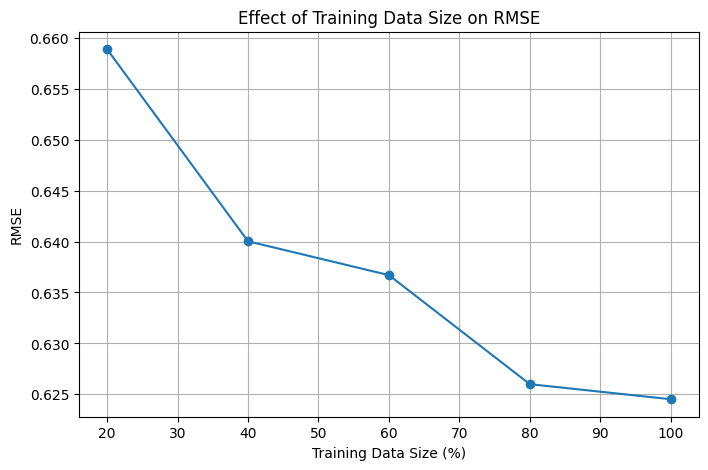

In [23]:
plt.figure(figsize=(8,5))

plt.plot(results_df["Training Size (%)"], results_df["RMSE"], marker="o")

plt.xlabel("Training Data Size (%)")

plt.ylabel("RMSE")

plt.title("Effect of Training Data Size on RMSE")

plt.grid(True)

plt.show()

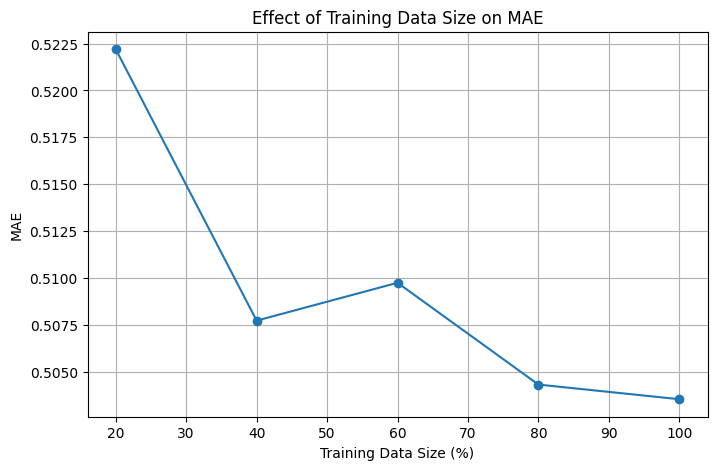

In [24]:
plt.figure(figsize=(8,5))

plt.plot(results_df["Training Size (%)"], results_df["MAE"], marker="o")

plt.xlabel("Training Data Size (%)")

plt.ylabel("MAE")

plt.title("Effect of Training Data Size on MAE")

plt.grid(True)

plt.show()

In [25]:
results_df.to_csv("training_data_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!
